In [ ]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

[0, 0, 1, 1]


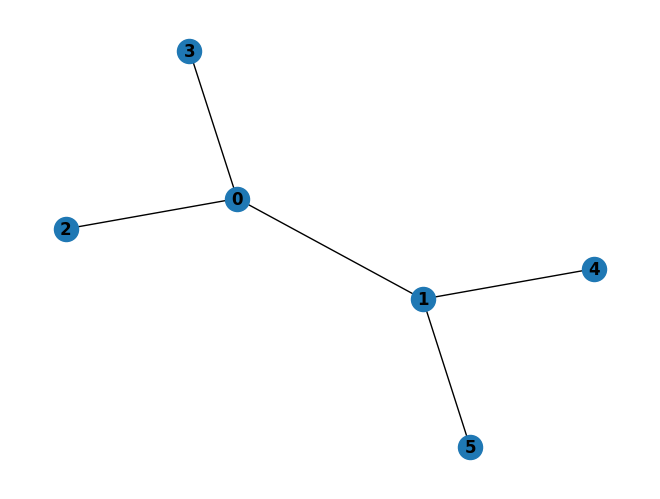

In [ ]:
N = 5
# V = [random.randint(0,N) for i in range(N)]
V = [0,0,1,1]
# random.shuffle(V)
T = nx.from_prufer_sequence(V)
print(V)
nx.draw(T, with_labels=True, font_weight='bold')

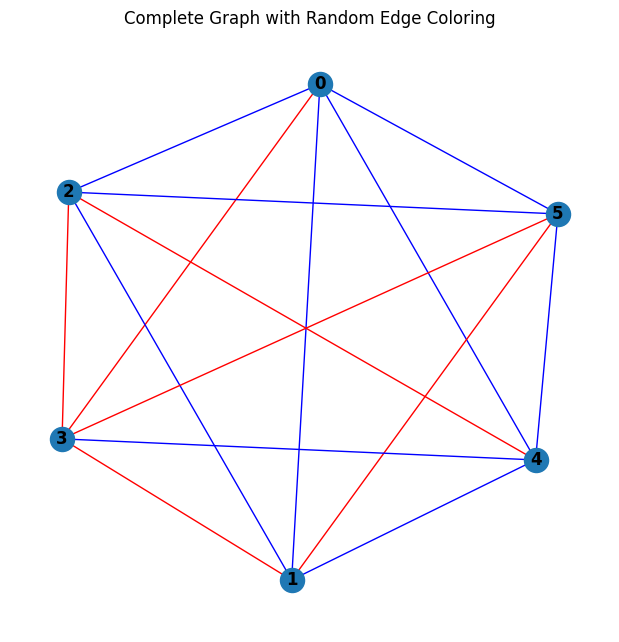

In [ ]:
N = 6
# Create a complete graph with N nodes
G_complete = nx.complete_graph(N)

# Define the possible colors
colors = ['red', 'blue']

# Create a dictionary to store edge colors
edge_colors = {}

# Randomly assign a color to each edge
for edge in G_complete.edges():
    edge_colors[edge] = random.choice(colors)

# Draw the graph with edge colors
plt.figure(figsize=(6, 6))
nx.draw(G_complete, with_labels=True, font_weight='bold', edge_color=[edge_colors[edge] for edge in G_complete.edges()])
plt.title("Complete Graph with Random Edge Coloring")
plt.show()

[(0, 1), (0, 2), (0, 6), (1, 3), (1, 7), (2, 7), (3, 0), (3, 1), (3, 4), (3, 5), (4, 1), (4, 6), (4, 7), (5, 1), (5, 2), (5, 3), (5, 6), (5, 7), (6, 1), (6, 5), (6, 7), (7, 0), (7, 2), (7, 3), (7, 4), (7, 5)]


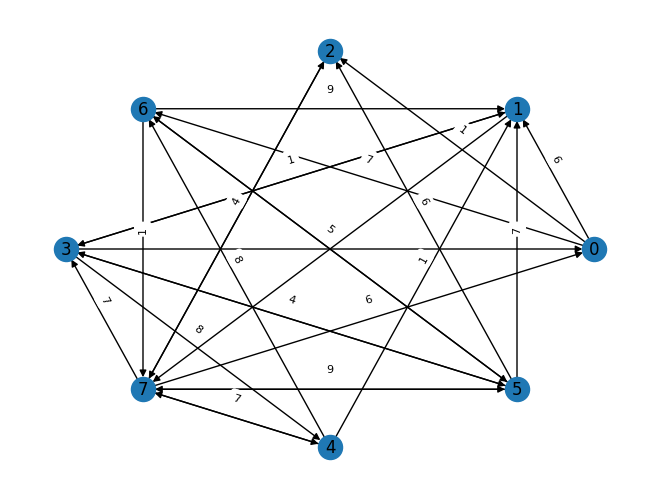

In [ ]:
# E = [(1,2),(1,8),(2,3),(2,8),(3,8),(3,5),(4,3),(4,5),(4,7),(6,2),(6,4),(7,6),(8,5)]
N = 8
p = 0.4
E = []
for i in range(N):
  for j in range(N):
    if random.random() < p  and i != j :
      # E.append((i+1,j+1))
      E.append((i,j))

print(E)


G = nx.DiGraph(E)
for (u,v) in G.edges():
  G[u][v]["weight"] = random.randint(1,10)
pos = nx.circular_layout(G, scale=1, center=(0, 0))
# ordered_nodes = [i+1 for i in range(N)]
ordered_nodes = [i for i in range(N)]
# Filter ordered_nodes to only include nodes present in the graph
ordered_nodes = [node for node in ordered_nodes if node in G.nodes()]

pos = {node: pos[node] for node in ordered_nodes}
edge_labels = nx.get_edge_attributes(G, 'weight')

# Adjust label positions
label_pos = {k: (v[0], v[1] + 0.1) for k, v in pos.items()} # Add a small offset

nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, label_pos, edge_labels=edge_labels, font_size=8); # Use adjusted positions and smaller font size


In [ ]:
from math import inf
def dijkstra(G,v):
  # print(nx.to_numpy_array(G))
  V = [node for node in  G.nodes()]
  E = [edge for edge in  G.edges()]
  T = nx.from_numpy_array(np.zeros((len(V),len(V))),nodelist=V)
  N = len(V)
  prev = [None]*N
  Q = V.copy()

  # init. distance
  d = {node : inf for node in G.nodes()}
  d[v] = 0
  u = v

  count = 0
  while Q :
    for w in G.neighbors(u):
      weight = G[u][w]["weight"]
      print(f"u = {u} , w = {w}")
      print(f"d[w] = {d[w]} , d[u] + weight(u,w) = {d[u]+ weight} ")
      if d[w] > G[u][w]["weight"] + d[u] :
        if w!= inf :
          if prev[w] != None:
            T.remove_edge(prev[w],w)
        d[w] = G[u][w]["weight"]  + d[u]
        neighbors = [neighbor for neighbor in  T.neighbors(u)]
        T.add_edge(u,w,weight=weight)
      prev[w] = u

    u = min(Q,key = lambda x : d[x])
    print(prev)
    print()
    Q.remove(u)

  return d,T
v = 0
d,T = dijkstra(G,v)
for key,val in d.items():
  print (key,val)


u = 0 , w = 1
d[w] = inf , d[u] + weight(u,w) = 6 
u = 0 , w = 2
d[w] = inf , d[u] + weight(u,w) = 1 
u = 0 , w = 6
d[w] = inf , d[u] + weight(u,w) = 7 
[None, 0, 0, None, None, None, 0, None]

u = 0 , w = 1
d[w] = 6 , d[u] + weight(u,w) = 6 
u = 0 , w = 2
d[w] = 1 , d[u] + weight(u,w) = 1 
u = 0 , w = 6
d[w] = 7 , d[u] + weight(u,w) = 7 
[None, 0, 0, None, None, None, 0, None]

u = 2 , w = 7
d[w] = inf , d[u] + weight(u,w) = 7 
[None, 0, 0, None, None, None, 0, 2]

u = 1 , w = 3
d[w] = inf , d[u] + weight(u,w) = 11 
u = 1 , w = 7
d[w] = 7 , d[u] + weight(u,w) = 10 
[None, 0, 0, 1, None, None, 0, 1]

u = 6 , w = 1
d[w] = 6 , d[u] + weight(u,w) = 16 
u = 6 , w = 5
d[w] = inf , d[u] + weight(u,w) = 12 
u = 6 , w = 7
d[w] = 7 , d[u] + weight(u,w) = 8 
[None, 6, 0, 1, None, 6, 0, 6]

u = 7 , w = 0
d[w] = 0 , d[u] + weight(u,w) = 13 
u = 7 , w = 2
d[w] = 1 , d[u] + weight(u,w) = 11 
u = 7 , w = 3
d[w] = 11 , d[u] + weight(u,w) = 14 
u = 7 , w = 4
d[w] = inf , d[u] + weight(u,w) = 8 
u = 7 ,

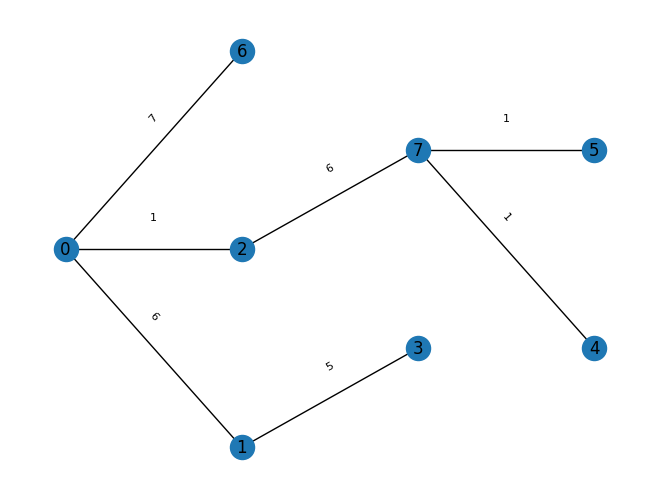

In [ ]:
T_ = T.subgraph(nx.node_connected_component(T, v))
pos = nx.circular_layout(T_, scale=1, center=(0, 0))
pos = nx.bfs_layout(T_,v)
ordered_nodes = [i for i in range(len(T_.nodes))]
pos = {node: pos[node] for node in ordered_nodes}
edge_labels = nx.get_edge_attributes(T_, 'weight')

# Adjust label positions
label_pos = {k: (v[0], v[1] + 0.1) for k, v in pos.items()} # Add a small offset

nx.draw(T_, pos, with_labels=True)
nx.draw_networkx_edge_labels(T_, label_pos, edge_labels=edge_labels, font_size=8); # Use adjusted positions and smaller font size

In [ ]:
def FloydWarshall(G):
  N = len(G.nodes)
  d = np.zeros_like(nx.to_numpy_array(G))
  prev = np.zeros_like(nx.to_numpy_array(G))

  # init. every self loop is 0 and unknown is inf.
  d = 1/d
  for u,v in G.edges:
    d[u,v] = G[u][v]["weight"]
    prev[u,v] = u
  for v in G.nodes:
    d[v,v] = 0
    prev[v,v] = v
  for k in range(N):
    for i in range(N):
      for j in range(N):
        if d[i,j] > d[i,k] + d[k,j]:
          d[i,j] = d[i,k] + d[k,j]
          prev[i,j] = prev[k,j]
  return d,prev

def reconstruct_path(u,v,G) :
  if prev[u,v] == 0 : return [],inf
  path = [v]
  while u != v :
    v = int(prev[u,v])
    path.append(v)

  total_distance = 0
  for i in range(len(path)-1):
    total_distance += G[path[i+1]][path[i]]["weight"]
  return path,total_distance



d,prev = FloydWarshall(G)
print(f"d = \n {d}\n")
print(f"prev = \n {prev}\n")

u = 0
v = len(G.nodes)//2
path,distance = reconstruct_path(u,v,G)
print(f"shortest path from {u} to {v} is : \n{path}\n with length :\n {distance}")


d = 
 [[ 0.  6.  1. 11.  8.  8.  7.  7.]
 [ 7.  0.  8.  5.  5.  5. 10.  4.]
 [12.  8.  0. 11.  7.  7. 12.  6.]
 [ 2.  1.  3.  0.  6.  6.  9.  5.]
 [ 8.  1.  9.  6.  0.  6.  8.  5.]
 [ 6.  5.  6.  4.  7.  0.  5.  6.]
 [ 7.  3.  5.  6.  2.  2.  0.  1.]
 [ 6.  2.  4.  5.  1.  1.  6.  0.]]

prev = 
 [[0. 0. 0. 1. 7. 7. 0. 2.]
 [3. 1. 0. 1. 7. 7. 5. 1.]
 [7. 4. 2. 5. 7. 7. 5. 2.]
 [3. 3. 0. 3. 7. 7. 0. 1.]
 [3. 4. 0. 1. 4. 7. 4. 1.]
 [3. 3. 5. 5. 7. 5. 5. 6.]
 [7. 4. 7. 5. 7. 7. 6. 6.]
 [7. 4. 7. 5. 7. 7. 5. 7.]]

shortest path from 0 to 4 is : 
[4, 7, 2, 0]
 with length :
 8


/tmp/ipython-input-2079153311.py:7: RuntimeWarning: divide by zero encountered in divide
  d = 1/d


0 1
1 3
3 4
4 6
6 5
5 2
2 7


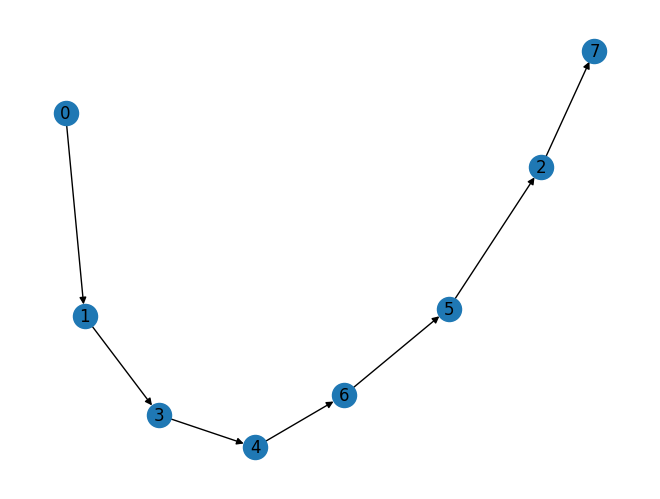

In [ ]:

def DFS_visit(G,U,u,p):
  for v in G.neighbors(u):
    if v in U:
      U.remove(v)
      p[u].append(v)
      print(u,v)
      return DFS_visit(G,U,v,p)

def DFS(G,p = {}):
  U = [node for node in G.nodes]
  p = {node:[] for node in G.nodes}
  for v in G.nodes:
    if v in U :
      U.remove(v)
      DFS_visit(G,U,v,p)
  return p

p = DFS(G)

T_DFS = nx.DiGraph(p)
nx.draw(T_DFS,with_labels =True)

In [ ]:
C = nx.greedy_color(G)
# nx.draw(G,with_labels = True )
# # nx.draw_networkx_nodes(G,node_color=C)